# ML Problem Framing and the Industry Workflow

**Applied ML in Production · Session 1**

---

A team can know a dozen algorithms, explain gradient descent on a whiteboard, sit
down in front of a real business problem — and freeze. Knowing the tools is not
knowing the process.

Projects rarely fail because someone chose logistic regression over a random
forest. They fail because "success" was never defined, because a crucial field
did not exist when the model ran, or because the model worked and nobody used it.

So this session covers the process before the modelling: the map the industry
follows, and its first stop — turning a sentence a manager says into a
specification an engineer can build and a business can judge.

We write no clever model today. We decide what "good" means.

## How to work through this

Run every code cell (`Shift + Enter`), look at the output, *then* read the
commentary underneath. The code here is deliberately short — counting, sorting,
one logistic regression — because today's difficulty is judgement, not syntax.

Cells build on each other, so if something errors, run from the top.

## Learning objectives

After this session you will be able to:

- Name the six phases of the **CRISP-DM** workflow and say what each one asks.
- Trace a business request back to the **decision** it is supposed to change.
- Apply a checklist that separates problems ML can help with from problems it
  cannot, and name three cases where the right answer is "do not use ML".
- Frame one business request as four different ML problems and explain what each
  framing costs and buys.
- Write an ML specification: target, unit, population, decision point, horizon,
  output, metric, constraints.
- Build **baselines** before modelling and use them to set the bar a model must clear.
- Produce a project charter that the rest of this module builds on.

## Setup

One cell, run once. It loads the module's spine dataset — about 12,000 SME loan
applications from a Nepali lender, spanning 2023 and 2024.

The `find_data` helper walks up from wherever the notebook is running until it
finds the repository's `data/` folder, so the notebook works no matter which
directory you started Jupyter from.

In [1]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True, "grid.alpha": 0.3})
pd.set_option("display.width", 120)


def find_data(filename="loan_default.csv"):
    for folder in [Path.cwd(), *Path.cwd().parents]:
        candidate = folder / "data" / filename
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"could not find data/{filename}")


loans = pd.read_csv(find_data(), parse_dates=["application_date"])

print(f"{len(loans):,} applications, {loans.shape[1]} columns")
print(f"default rate: {loans['defaulted'].mean():.1%}")
loans.head(3)

12,000 applications, 15 columns
default rate: 13.5%


,loan_id,application_date,branch,sector,employment_type,loan_amount,tenure_months,interest_rate,annual_income,credit_score,has_collateral,previous_loans,days_past_due_history,recovery_agent_assigned,defaulted
0,NL200000,2023-01-01,Birgunj-01,Service,Business Owner,417000.0,36,10.28,194000.0,652.0,Yes,2,40,Yes,1
1,NL200001,2023-01-01,Biratnagar-03,Service,Self-Employed,154000.0,12,9.82,NaN,695.0,Yes,1,0,No,0
2,NL200002,2023-01-01,Kathmandu-03,Trade,Salaried,163000.0,24,13.04,948000.0,565.0,No,2,22,No,0


---

## 1. The map: CRISP-DM

Before touching the problem, here is the map. **CRISP-DM** — the Cross-Industry
Standard Process for Data Mining — is a checklist of the six stages nearly every
data project moves through. It was written in the late 1990s and it is still the
default playbook in industry, because the shape of the work has not changed.

| # | Phase | The question it asks |
|---|-------|----------------------|
| 1 | **Business Understanding** | What are we trying to achieve, and how will we know we succeeded? |
| 2 | **Data Understanding** | What data do we have, and what shape is it in? |
| 3 | **Data Preparation** | How do we turn raw data into something a model can eat? |
| 4 | **Modelling** | Which algorithm, trained how? |
| 5 | **Evaluation** | Did it work, and is it good enough to trust? |
| 6 | **Deployment** | How does it reach the person who makes the decision, and stay healthy? |

<center>
<img src="images/crispdm.png" width="620">

*Fig: the CRISP-DM process. Note the arrows going backwards.*
</center>

Three things about that diagram are worth more than the phase names themselves.

**It is a loop, not a line.** Evaluation sends you back to business
understanding. Modelling sends you back to preparation. The arrow you travel most
often in a real project points backwards.

**Data sits in the middle.** Every phase touches it, and every phase can
contaminate it.

**The effort is front-loaded.** On typical projects, business understanding, data
understanding and data preparation together take roughly two thirds of the time.
Modelling — the part everyone shows up for — is nearer a tenth.

### What the phases involve

A little more detail, because the names are vague on their own:

- **Business Understanding** — define the problem, the people affected, the data
  and resources available, and what success will look like. Today.
- **Data Understanding** — acquire the data (files, databases, web scraping and
  APIs, streams) and explore it: summaries, distributions, correlations, quality
  checks. Data is **structured** (tables, like ours) or **unstructured** (text,
  images, audio) — most of the world's data is the second kind.
- **Data Preparation** — clean, encode, transform, split. The biggest slice of
  the work on nearly every project.
- **Modelling** — choose an algorithm, train it, tune it.
- **Evaluation** — check it against the success criteria, not just the metric,
  and find where it fails.
- **Deployment** — three parts that students always underestimate: write up what
  you built, wrap the model in something the world can call, and monitor it for
  quiet decay.

> A complete CRISP-DM walkthrough on a different problem — predicting school
> grades, all six phases in one sitting — is in
> `reference/MLWorkflow.ipynb`. Read it alongside this module if you want the
> whole loop end to end before we take it slowly, phase by phase.

### The module on one map

Each of our ten sessions lives somewhere on that loop:

| CRISP-DM phase | Sessions |
|----------------|----------|
| 1. Business Understanding | **Session 1 — today** |
| 2. Data Understanding | Session 2 |
| 3. Data Preparation | Sessions 2, 3 |
| 4. Modelling | Sessions 4, 6, 7 |
| 5. Evaluation | Sessions 5, 6 |
| 6. Deployment | Sessions 8, 9, 10 |

Today is Phase 1 in full. It is the phase everyone is tempted to skip and the one
that most often decides whether the project lives.

---

## 2. Phase 1 — Business Understanding

Phase 1 asks six questions. The infographic below is the version pinned above
many an industry desk; the Business Understanding ring at the top is our whole
session.

<center>
<img src="images/crispdminfographics.png" width="760">

*Fig: CRISP-DM in detail. Phase 1 — the ring at the top — is today.*
</center>

| Phase 1 question | Where we answer it |
|------------------|--------------------|
| What will you do differently? | Section 2, below |
| Who will be impacted? | Section 2 |
| What are the risks? | Section 3 |
| How much will errors cost? | Section 6 |
| How will you measure success? | Section 7 |
| Who can help? | The charter, section 8 |

### The request

Here is the email. Yours will look almost exactly like this.

> *"Our default rate is climbing and the credit team can't keep up with volume.
> Decisions are inconsistent between branches. Can we use AI to predict which
> loans will go bad?"*
> — Head of Credit

That is a complaint plus a proposed solution. It is not yet a problem statement.
Ask three questions, in this order.

**1. What decision does this change?**
Not "what would we predict" — what would somebody *do differently*. If the honest
answer is "we would understand our risk better", stop. Knowing is not doing. Here
the candidate decisions are: approve or decline, price differently, require
collateral, or send the file to a senior officer.

**2. Who makes that decision, and when?**
A credit officer, when the application is submitted, before any money moves. That
moment is the **decision point**, and it fixes what information the model may
use. Anything recorded later is off limits — it will not exist on the day.

**3. What do they do today, and how well does it work?**
Manual assessment against a policy document. "How well" is a number we compute in
section 5, and it becomes the bar the model must clear.

applications per month: about 498
branches: 40
applications per branch per month: about 12


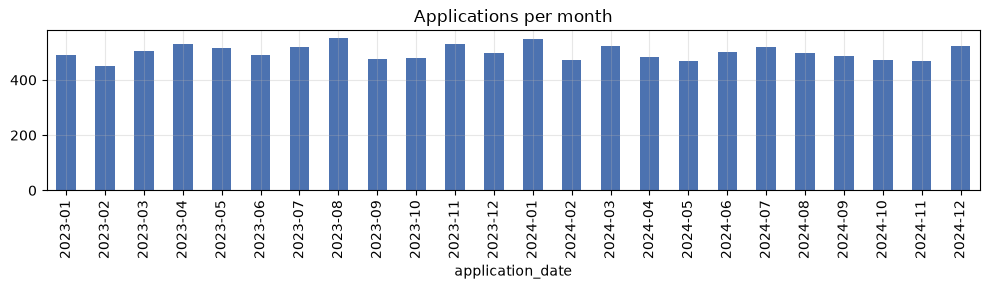

In [2]:
# How often is this decision made? Volume is what justifies automating anything.
per_month = loans.groupby(loans["application_date"].dt.to_period("M")).size()

print(f"applications per month: about {per_month.median():.0f}")
print(f"branches: {loans['branch'].nunique()}")
print(f"applications per branch per month: about {per_month.median() / loans['branch'].nunique():.0f}")

per_month.plot.bar(color="#4C72B0", title="Applications per month", figsize=(10, 3))
plt.tight_layout()
plt.show()

About 500 applications a month, roughly 12 per branch. That single number tells
us three things:

- It is **enough volume to be worth automating**. A decision made twice a year
  needs a good afternoon of analysis, not a model.
- It is **low enough to keep a human in the loop**. Twelve files per branch per
  month can be reviewed by hand, which makes "rank the risky ones for review" a
  realistic design — remember that in section 4.
- The **latency requirement is trivial**: a few seconds is plenty. That removes a
  whole category of engineering complexity from the project.

> **Industry note — the model nobody used.**
> The commonest failure in industry is not a bad model; it is a good model that
> changes no decision. Scores appear in a dashboard, nobody is accountable for
> acting on them, and the project quietly ends. Before writing code, name the
> person whose workflow changes and the button they press. If you cannot, you are
> building a report — and a report has a much cheaper implementation.

---

## 3. Is this a machine learning problem at all?

Machine learning earns its place under specific conditions. Run the checklist
before committing.

| # | Condition | This problem |
|---|-----------|--------------|
| 1 | The decision is **repeated** at volume | ~500 a month, yes |
| 2 | The outcome is **recorded** as data | `defaulted` exists for past loans, yes |
| 3 | The pattern is real but **not a simple stable rule** | Risk depends on several interacting factors, yes |
| 4 | The past **resembles** the future | Partly — lending conditions change. Record this as a risk |
| 5 | Errors are **survivable** and their costs known | A wrong decline annoys; a wrong approve costs money. Both bounded |
| 6 | Someone will **act** on the output | A credit officer, at submission, yes |

Condition 4 is the one people wave through. Write it down as a risk now; session
8 measures what happens when the world moves under a model that assumed it would not.

### When the answer is "do not use ML"

- **A rule already works.** If policy says "decline anyone with an unpaid
  judgement", implement the rule. A model that learns an existing rule adds
  failure modes and subtracts transparency.
- **There are no labels.** "Predict which customers are unhappy", with no record
  of unhappiness, is a data-collection project wearing an ML costume.
- **The decision is one-off.** Choosing a head office location is analysis.
- **The explanation must be legal, not statistical.** If a regulator demands the
  exact reason for every decline, your model choices narrow sharply.
- **The inputs will not exist at decision time.** The strongest column in your
  extract may be recorded only after the outcome. Hold that thought — it is the
  whole of session 2.

---

## 4. Four ways to frame the same request

"Predict which loans go bad" maps onto at least four different ML problems. Same
data, completely different systems.

| Framing | Target | Output | Decision it supports | What it costs you |
|---------|--------|--------|----------------------|-------------------|
| **Binary classification** | `defaulted` (0/1) | approve / decline | Automated accept–reject | Throws away *how* risky; needs a threshold someone must own |
| **Regression** | rupees lost on this loan | a number | Risk-based pricing, provisioning | We do not have this target — it would need recovery records |
| **Ranking** | a risk score | a queue | "Review the riskiest 20% by hand" | States no decision itself; a human must act on the order |
| **Unsupervised** | none | applicant segments | Portfolio understanding, policy design | No target, so no direct accuracy claim |

What changes between the rows is not the algorithm — it is the **label** and the
**shape of the deployed system**. Framing is a product decision that happens to be
made by the data person.

Ranking suits this business better than students expect. With 12 files per branch
per month, the lender does not need a machine that says yes or no. It needs one
that says *look at these six first*.

The plot below is a **capture curve**: review the riskiest X% of applications by
hand, and what share of all defaults do you get in front of?

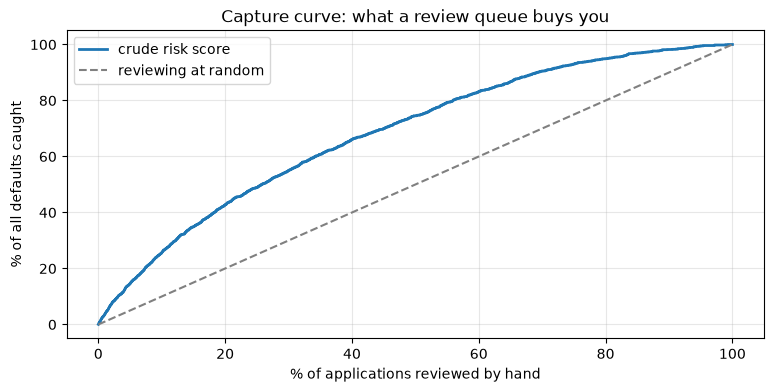

reviewing the riskiest 20% catches 43% of all defaults


In [3]:
# A crude risk score — no model, just arithmetic on two obvious risk drivers.
# (Missing credit scores are filled with the median to keep this simple;
#  session 2 shows why that shortcut is not free.)
score = (700 - loans["credit_score"].fillna(640)) / 100 + loans["days_past_due_history"] / 45

ranked = loans.assign(score=score).sort_values("score", ascending=False)
caught = ranked["defaulted"].cumsum() / ranked["defaulted"].sum() * 100
reviewed = np.arange(1, len(ranked) + 1) / len(ranked) * 100

plt.plot(reviewed, caught, label="crude risk score", linewidth=2)
plt.plot([0, 100], [0, 100], "--", color="grey", label="reviewing at random")
plt.xlabel("% of applications reviewed by hand")
plt.ylabel("% of all defaults caught")
plt.title("Capture curve: what a review queue buys you")
plt.legend()
plt.show()

print(f"reviewing the riskiest 20% catches {caught.iloc[int(0.20 * len(ranked))]:.0f}% of all defaults")

Two lines of arithmetic, no training, and the queue already finds twice as many
defaults as reviewing the same number of files at random. That is a picture you
can put in front of the Head of Credit without naming a single algorithm.

For the rest of the module we take the **binary classification** framing: it
supports an automated decision, and its metrics (session 5) are the ones the
syllabus is built around. Keep ranking in your pocket — it is often what ships
first, because it keeps a human in the loop while trust is earned.

---

## 5. From business objective to ML specification

This is the translation step. A business objective is a sentence about money or
risk. An ML objective is a precise statement about a target variable. They are
never the same sentence.

| Business objective | ML objective |
|--------------------|--------------|
| "Reduce credit losses without shrinking the book" | "Predict, at application time, the probability that a loan will be recorded as defaulted within 12 months" |

Everything vague has been removed: *when* we predict, *what* we predict, over
*what horizon*, in *what form* — a probability, not a yes/no, because the
threshold is a separate business-owned decision (session 5).

The same move works on any request. A school wants to *"spot students at risk of
a poor final grade early enough to help them"*. A counsellor can only reach a
handful of students, so the wish becomes: *"predict a student's final grade from
information available at the start of the year, and be within about two grade
points"* — a regression problem with a stated tolerance. That worked example runs
end to end in `reference/MLWorkflow.ipynb`.

A complete specification answers nine questions.

| Field | This project |
|-------|--------------|
| **Target** | `defaulted` — 1 if the loan was recorded as defaulted |
| **Unit of prediction** | One loan application |
| **Population** | SME working-capital applications, all 40 branches |
| **Decision point** | Application submitted, before disbursement |
| **Features** | Only fields that exist *at that moment* |
| **Horizon** | Default observed within 12 months of disbursement |
| **Output** | A probability between 0 and 1 |
| **Offline metric** | Chosen in session 5 |
| **Constraints** | Seconds per decision; declines must be explainable; no protected attributes |

### The point-in-time rule

> For every column, ask: **would this value exist, for this applicant, at the
> moment the decision is made?** If the answer is "no" or "not sure", it is not a
> feature until somebody proves otherwise.

This sounds obvious and is broken constantly, because extracts are assembled from
whatever the warehouse holds *today* — including columns written long after the
decision was made. A model trained on those looks superb in a notebook and
collapses in production, where they are empty.

In [4]:
TARGET = "defaulted"
candidate_features = [c for c in loans.columns if c not in ["loan_id", "application_date", TARGET]]

print(f"target: {TARGET}")
print(f"{len(candidate_features)} candidate features:")
print(", ".join(candidate_features))
print("\nCandidate, not confirmed — each one still has to pass the point-in-time rule.")

target: defaulted
12 candidate features:
branch, sector, employment_type, loan_amount, tenure_months, interest_rate, annual_income, credit_score, has_collateral, previous_loans, days_past_due_history, recovery_agent_assigned

Candidate, not confirmed — each one still has to pass the point-in-time rule.


Auditing that list is the first exercise at the end of this notebook, and session
2 opens with the answer.

> **Industry note — the warehouse contains the future.**
> Warehouse tables are updated as life happens: a customer status is overwritten
> when the customer churns, a case owner is filled in when a case is opened.
> Query that table a year later and every row quietly contains information from
> *after* the moment you are pretending to stand in. This is why mature teams
> keep dated snapshots rather than live tables.

---

## 6. Baselines before models

A baseline is a cheap method whose score you must beat to justify anything more
expensive. Three levels, always in this order:

1. **Constant** — always predict the majority class. Exposes metrics that lie.
2. **Rule** — the heuristic the business already uses. This is what you are
   replacing, so this is the real bar.
3. **Simple model** — logistic regression on a few obvious features. Tells you
   what "easy machine learning" is worth here.

Only then does anything complicated get to enter the conversation.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split

FEATURES = ["loan_amount", "tenure_months", "interest_rate", "previous_loans"]

X = loans[FEATURES]
y = loans[TARGET]

# A random, stratified split. How to split properly is itself a design decision — session 2.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)
print(f"train {len(X_train):,} rows, test {len(X_test):,} rows")

train 9,000 rows, test 3,000 rows


In [6]:
predictions = {}

# 1. Constant: nobody ever defaults.
predictions["always predict 'repaid'"] = np.zeros(len(y_test), dtype=int)

# 2. The existing policy rule (a missing score means the rule stays silent).
credit_score = loans.loc[X_test.index, "credit_score"].fillna(999)
predictions["rule: credit_score < 600"] = (credit_score < 600).astype(int).to_numpy()

# 3. Logistic regression on four obvious features.
model = LogisticRegression(max_iter=1000, class_weight="balanced").fit(X_train, y_train)
predictions["logistic regression"] = model.predict(X_test)

results = pd.DataFrame({
    name: {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "flagged": y_pred.mean(),
    }
    for name, y_pred in predictions.items()
}).T.round(3)

print(results.to_string())

                          accuracy  precision  recall  flagged
always predict 'repaid'      0.865      0.000   0.000    0.000
rule: credit_score < 600     0.695      0.230   0.536    0.314
logistic regression          0.696      0.253   0.642    0.342


Read that table slowly, because it contains the most important trap in applied
machine learning.

**The do-nothing baseline has the best accuracy.** Predicting that nobody ever
defaults is right 86.5% of the time and catches zero defaults. Any project
reporting "86% accuracy" on this dataset has reported nothing at all.

The rule catches about half the defaults, at the cost of flagging a third of the
book. The logistic regression catches more and flags more. Neither is good yet —
their job today is to be the number the real work must beat.

Change the metric and the winner changes. That is the normal state of affairs,
and it is why the metric must be agreed *before* modelling starts. Session 5 is
devoted to choosing it properly.

### Bringing money into it

Metrics are proxies. The business cares about rupees. Any set of predictions
becomes a cost estimate as soon as we state two numbers:

- A **missed default** (approved, then defaulted) loses roughly 55% of the loan
  amount after recovery.
- A **false alarm** (declined a loan that would have been repaid) loses the
  interest margin, roughly 4.5% of the loan amount.

Both are guesses until the credit team confirms them — and getting them confirmed
is your job, not theirs.

In [7]:
amounts = loans.loc[X_test.index, "loan_amount"].to_numpy()
actual = y_test.to_numpy()

for name, y_pred in predictions.items():
    missed = amounts[(actual == 1) & (y_pred == 0)].sum() * 0.55
    false_alarm = amounts[(actual == 0) & (y_pred == 1)].sum() * 0.045
    print(f"NPR {missed + false_alarm:>13,.0f}   {name}")

NPR   103,513,300   always predict 'repaid'
NPR    64,961,030   rule: credit_score < 600
NPR    44,181,625   logistic regression


The ordering just flipped. Under accuracy, "never decline anyone" won. Under
money it is the most expensive option on the table, because a missed default
costs about twelve times what a false alarm does.

That is the point of framing: same predictions, same data, two different
conclusions — and only one of them is the conclusion the business acts on.

Do not over-read the numbers. The costs are invented, the split is naive, the
features are minimal. What matters is the habit: state the costs, compute the
money, and let it argue with the metric.

---

## 7. Success criteria you can be held to

"Make the model as accurate as possible" is not a success criterion. It has no
stopping point, no owner, and no link to the business. A usable one has four parts.

**1. An offline metric with a number.** Anchored to a baseline: *"catch at least
60% of defaults while flagging no more than 25% of applications"* is checkable.
*"High recall"* is not.

**2. A business metric.** The number the project is judged on, in the unit the
business speaks — rupees of credit loss avoided, net of lost margin, per quarter.

**3. Guardrails.** Things that must not get worse even if the headline metric
improves: latency, decline rates in any one branch, explainability, and the
absence of protected attributes.

**4. Kill criteria.** The conditions under which the project stops. Writing these
while everyone is calm is the most valuable ten minutes of a project.

In [8]:
CRITERION_RECALL = 0.60      # catch at least 60% of defaults
CRITERION_FLAGGED = 0.25     # while flagging at most 25% of applications

for name, row in results.iterrows():
    passes = row["recall"] >= CRITERION_RECALL and row["flagged"] <= CRITERION_FLAGGED
    print(f"{'PASSES' if passes else 'fails ':<7} {name:<26} recall {row['recall']:.2f}, flags {row['flagged']:.0%}")

fails   always predict 'repaid'    recall 0.00, flags 0%
fails   rule: credit_score < 600   recall 0.54, flags 31%
fails   logistic regression        recall 0.64, flags 34%


Nothing passes. That is the correct state at the end of session 1 — we now have a
target worth five weeks of work.

---

## 8. The project charter

Everything above compresses onto one page that the whole project refers back to.
Write it, circulate it, get it agreed, and revisit it when something changes.

Sessions 2 to 10 keep returning to this charter: when session 5 picks a metric it
is filling in a field here; when session 8 detects drift it is testing an
assumption recorded here.

In [9]:
CHARTER = {
    "project": "SME loan default prediction",
    "business_problem": "Manual assessment cannot keep up with ~500 applications a month; "
                        "decisions are inconsistent across 40 branches and losses are rising.",
    "decision_changed": "At submission, route an application to auto-approve, senior review, or decline.",
    "decision_owner": "Head of Credit",
    "ml_task": "binary classification, probability of default",
    "target": "defaulted, observed within 12 months of disbursement",
    "unit_of_prediction": "one loan application, scored at submission",
    "baseline_to_beat": "the credit_score < 600 policy rule",
    "offline_criterion": "recall >= 0.60 while flagging <= 25% of applications",
    "business_criterion": "quarterly credit losses down >= 15%, net of lost margin",
    "guardrails": "decision in seconds; declines explainable; no protected attributes",
    "kill_criteria": "does not beat the policy rule at an equal decline rate",
    "known_risks": "lending conditions may shift; some columns may not exist at decision time",
}

for field, value in CHARTER.items():
    print(f"\n{field.replace('_', ' ').upper()}\n  {value}")


PROJECT
  SME loan default prediction

BUSINESS PROBLEM
  Manual assessment cannot keep up with ~500 applications a month; decisions are inconsistent across 40 branches and losses are rising.

DECISION CHANGED
  At submission, route an application to auto-approve, senior review, or decline.

DECISION OWNER
  Head of Credit

ML TASK
  binary classification, probability of default

TARGET
  defaulted, observed within 12 months of disbursement

UNIT OF PREDICTION
  one loan application, scored at submission

BASELINE TO BEAT
  the credit_score < 600 policy rule

OFFLINE CRITERION
  recall >= 0.60 while flagging <= 25% of applications

BUSINESS CRITERION
  quarterly credit losses down >= 15%, net of lost margin

GUARDRAILS
  decision in seconds; declines explainable; no protected attributes

KILL CRITERIA
  does not beat the policy rule at an equal decline rate

KNOWN RISKS
  lending conditions may shift; some columns may not exist at decision time


Notice how little of that page is about machine learning. The decision, the
owner, the bar, the conditions for stopping — a business reader can check every
one without knowing what logistic regression is. That is the test of a good charter.

---

## 9. The whole journey on one page

| CRISP-DM phase | What it asks | What we did today | Where it is finished |
|----------------|--------------|-------------------|----------------------|
| 1. Business Understanding | What are we solving, and what is success? | Named the decision, framed it as classification, set baselines and a charter | **Done today** |
| 2. Data Understanding | What have we got? | Listed 12 candidate features and flagged the point-in-time question | Session 2 |
| 3. Data Preparation | Make it model-ready | — | Sessions 2–3 |
| 4. Modelling | Which model, trained how? | A four-feature logistic regression, as a baseline only | Sessions 4, 6, 7 |
| 5. Evaluation | Is it good enough to trust? | Wrote the criterion; nothing passes it yet | Sessions 5–6 |
| 6. Deployment | How does it reach the decision-maker? | Recorded the latency and explainability constraints | Sessions 8–10 |

Phase 1 is complete: we started with a fuzzy complaint and ended with a written
charter, three measured baselines, and a number to beat.

---

## Your turn

**1. The availability audit.** Go through all 15 columns and sort them into
*known at application time*, *not known until later*, and *not sure*. For each
column in the last two groups, write one sentence saying what you would ask the
credit team. Keep this list — session 2 opens with it.

**2. Name the decision.** Take a different request — "predict which customers
will churn", "predict machine failures", "predict which tickets will escalate" —
and answer the three questions from section 2. If you cannot name the decision
that changes, say so explicitly; that is a valid and valuable finding.

**3. Reframe.** Write the specification for the **ranking** framing instead of
classification: target, output, what the credit officer sees, what you report.
Which framing would you recommend to the Head of Credit, and why?

**4. Move the cost assumptions.** Re-run the money cell with the missed-default
cost at 0.30 (strong recovery) and again at 0.80 (weak recovery). At what point
does "never decline anyone" stop being the worst option? What does that say about
how carefully those numbers need to be agreed?

**5. Set the bar.** Justify or change the 60% recall / 25% flagged criterion
using the capture curve in section 4 and the review capacity implied by 12
applications per branch per month.

**6. Write your own charter.** Fill in the `CHARTER` template for a problem from
your workplace, degree project, or a dataset you like. Bring it next session —
the fields you cannot fill are the instructive ones.

---

## If you remember nothing else

**Machine learning is a process, not a model.** CRISP-DM names the six phases,
and the arrows that matter most point backwards.

**A model that changes no decision is a report.** Start from the decision, the
person making it, and the moment they make it — not from the data.

**Framing is the design.** The same request becomes classification, regression,
ranking or segmentation depending on the decision it serves. That choice fixes
your label, your metric and your deployment shape, and it is far harder to change
later than any hyperparameter.

**Baselines are competitors.** A constant, a rule, and a simple model. On
imbalanced data the do-nothing baseline beats you on accuracy every time.

**State success before you start.** An offline metric with a number, a business
metric in money, guardrails, and the conditions under which you stop.

**Only use features that exist at the decision point.** Everything else is the
future leaking backwards — and it is the subject of the next session.

---

## Glossary

| Term | Meaning |
|------|---------|
| **CRISP-DM** | The six-phase process most data projects follow |
| **Decision point** | The moment the prediction is used; fixes what data may be a feature |
| **Unit of prediction** | What one row and one prediction refer to — here, one application |
| **Horizon** | The window in which the outcome is observed (12 months) |
| **Baseline** | A cheap alternative whose score a real model must beat |
| **Capture curve** | Share of positives found against share of cases reviewed |
| **Point-in-time correctness** | Using only values that existed at the decision point |
| **Guardrail** | A quantity that must not degrade, even if the headline metric improves |
| **Kill criteria** | Pre-agreed conditions for stopping the project |
| **Class imbalance** | One class far rarer than the other — 13.5% defaults here |
| **Charter** | The one-page agreement fixing problem, decision, bar, and risks |

## Further reading

- Google, *Introduction to Machine Learning Problem Framing* — short, and the
  industry reference for this session.
- Chip Huyen, *Designing Machine Learning Systems*, chapters 1–2 — business
  objectives versus ML objectives.
- Emmanuel Ameisen, *Building Machine Learning Powered Applications*, chapters
  1–3 — framing and baselines, worked through.
- Wirth and Hipp, *CRISP-DM: Towards a Standard Process Model for Data Mining*
  (2000) — the original six-phase paper.

---

**Next session:** *Data Preparation for ML* — cleaning, missing values, encoding,
scaling, splitting, and a hunt for the column in this dataset that should never
have been in the file.